In [1]:
import pandas as pd

In [12]:

data = pd.read_csv('/content/Substrate_encoding.csv')

In [3]:
data

,Unnamed: 0.1,Unnamed: 0,Substrate,Enzyme,Encoding_diamension1,Encoding_diamension2,Encoding_diamension3,Encoding_diamension4,Encoding_diamension5,Encoding_diamension6,...,Encoding_diamension631,Encoding_diamension632,Encoding_diamension633,Encoding_diamension634,Encoding_diamension635,Encoding_diamension636,Encoding_diamension637,Encoding_diamension638,Encoding_diamension639,Encoding_diamension640
0,0,0,MSFTLTN|KNVIFVAGLG,Aspartic,-0.153657,0.023715,0.187349,-0.042719,-0.157723,-0.103581,...,0.065944,0.064247,-0.457378,0.211027,0.004751,0.250570,-0.016465,0.168246,-0.346152,-0.037509
1,1,1,MSFTLTNKN|VIFVAGLGGI,Aspartic,-0.114211,0.027532,0.172371,-0.053970,-0.122706,-0.105176,...,0.061269,0.033611,-0.490616,0.260386,-0.023814,0.233772,0.001717,0.134667,-0.350333,-0.009931
2,2,2,FTLTNKNVIF|VAGLGGIGLD,Aspartic,-0.161038,0.091819,0.171918,-0.079248,-0.173976,-0.010149,...,0.109995,-0.016751,-0.645607,0.260765,-0.007248,0.169314,-0.015100,0.177599,-0.349704,0.034031
3,3,3,NVIFVAGLGG|IGLDTSKELL,Aspartic,-0.124974,-0.074787,0.127263,-0.091683,-0.066782,-0.160926,...,0.068008,-0.043218,-0.097032,0.234022,-0.024388,0.091861,0.048040,0.053329,-0.246384,0.123559
4,4,4,IFVAGLGGIG|LDTSKELLKR,Aspartic,-0.148555,-0.030352,0.124166,-0.128930,-0.108213,-0.111103,...,0.023090,-0.063995,-0.139887,0.130608,0.040431,0.121032,0.054244,0.061066,-0.210348,0.111270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2328,2328,2328,MRRRKADSLE|VQQMKAQARE,Aspartic,-0.088165,-0.005635,0.171525,-0.135595,-0.060085,-0.095286,...,0.026994,-0.061153,-0.535291,0.085815,0.078208,0.080482,-0.159585,0.019598,-0.159517,-0.026221
2329,2329,2329,PADAPNPVVF|VATKDTRALR,Aspartic,-0.142782,0.103158,0.288046,0.038429,-0.286714,0.046693,...,0.001933,-0.104122,-0.704173,0.127215,0.045911,0.117127,-0.162132,0.143621,-0.293676,-0.119284
2330,2330,2330,EEDIPSPLNL|YGKTKLDGEK,Aspartic,-0.128691,0.024070,0.121731,-0.109669,0.021238,-0.007922,...,0.164825,0.018517,-0.482704,0.103568,0.089988,-0.003208,-0.077129,0.110956,-0.273833,-0.066209
2331,2331,2331,RGSDASDFDL|LETQSACSDT,Aspartic,-0.048833,0.106914,0.137186,-0.169955,-0.026970,-0.041431,...,0.089522,0.163196,-0.199701,0.131898,-0.018858,0.055671,-0.037194,0.033675,-0.162605,-0.039281


In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [14]:
df = data.copy()

In [15]:
print("Shape:", df.shape)
print("First 6 columns:", list(df.columns[:6]))
print("Last 3 columns:", list(df.columns[-3:]))
print("\nEnzyme values:", df["Enzyme"].unique())
print("\nEncoding cols found:", sum(c.startswith("Encoding") for c in df.columns))

enc = [c for c in df.columns if c.startswith("Encoding")]
nan_per_col = df[enc].isna().sum()
print("Columns that are entirely NaN:", (nan_per_col == len(df)).sum())
print("Rows with at least one NaN:", df[enc].isna().any(axis=1).sum(), "of", len(df))

Shape: (8299, 644)
First 6 columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Substrate', 'Enzyme', 'Encoding_diamension1', 'Encoding_diamension2']
Last 3 columns: ['Encoding_diamension638', 'Encoding_diamension639', 'Encoding_diamension640']

Enzyme values: ['Aspartic' 'Serine']

Encoding cols found: 640
Columns that are entirely NaN: 0
Rows with at least one NaN: 0 of 8299


In [16]:
enc_cols = [c for c in df.columns if c.startswith("Encoding")]
print(f"{len(enc_cols)} encoding columns")

X = df[enc_cols].apply(pd.to_numeric, errors="coerce").values.astype("float32")
y = df["Enzyme"].astype(str).str.strip().str.lower().map(
    {"aspartic": 0, "serine": 1}
).values.astype("int64")

n_features = X.shape[1]
print("Samples:", X.shape, "Class counts:", np.bincount(y))

# 70 / 20 / 10 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype("float32")
X_val   = scaler.transform(X_val).astype("float32")
X_test  = scaler.transform(X_test).astype("float32")

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val))
test_ds  = TensorDataset(torch.tensor(X_test),  torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

print(X_train.shape, X_val.shape, X_test.shape)

640 encoding columns
Samples: (8299, 640) Class counts: [4541 3758]
(5809, 640) (830, 640) (1660, 640)


In [21]:
# --- 1. Regularized architecture (dropout + batchnorm) ---
class ANN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 320), nn.BatchNorm1d(320), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(320, 160),    nn.BatchNorm1d(160), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(160, 64),     nn.ReLU(),           nn.Dropout(0.2),
            nn.Linear(64, 2),
        )
    def forward(self, x):
        return self.net(x)

model = ANN(n_features).to(device)

# --- 3. Class weights so Aspartic isn't ignored ---
w = torch.tensor(len(y_train) / (2 * np.bincount(y_train)), dtype=torch.float32).to(device)
print("Class weights:", w.cpu().numpy())
criterion = nn.CrossEntropyLoss(weight=w)

# --- 2. Weight decay ---
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# run_epoch is unchanged from before
def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)
    return total_loss / n, correct / n

# --- 4. Early stopping on validation loss ---
best, patience, wait = float("inf"), 3, 0
for epoch in range(1, 51):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader)
    print(f"Epoch {epoch:2d} | train_loss {tr_loss:.4f} train_acc {tr_acc:.4f} | "
          f"val_loss {va_loss:.4f} val_acc {va_acc:.4f}")
    if va_loss < best:
        best, wait = va_loss, 0
        torch.save(model.state_dict(), "best.pt")
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stop at epoch {epoch} (best val_loss {best:.4f})")
            break

model.load_state_dict(torch.load("best.pt"))
te_loss, te_acc = run_epoch(test_loader)
print(f"\nTest accuracy (best checkpoint): {te_acc:.4f}")

Class weights: [0.91365206 1.1043726 ]
Epoch  1 | train_loss 0.5864 train_acc 0.6991 | val_loss 0.5599 val_acc 0.7241
Epoch  2 | train_loss 0.5604 train_acc 0.7141 | val_loss 0.5504 val_acc 0.7217
Epoch  3 | train_loss 0.5530 train_acc 0.7175 | val_loss 0.5474 val_acc 0.7229
Epoch  4 | train_loss 0.5398 train_acc 0.7271 | val_loss 0.5356 val_acc 0.7217
Epoch  5 | train_loss 0.5290 train_acc 0.7411 | val_loss 0.5323 val_acc 0.7542
Epoch  6 | train_loss 0.5216 train_acc 0.7330 | val_loss 0.5369 val_acc 0.7193
Epoch  7 | train_loss 0.5046 train_acc 0.7471 | val_loss 0.5285 val_acc 0.7289
Epoch  8 | train_loss 0.4967 train_acc 0.7519 | val_loss 0.5445 val_acc 0.7169
Epoch  9 | train_loss 0.4894 train_acc 0.7531 | val_loss 0.5287 val_acc 0.7253
Epoch 10 | train_loss 0.4819 train_acc 0.7657 | val_loss 0.5328 val_acc 0.7325
Early stop at epoch 10 (best val_loss 0.5285)

Test accuracy (best checkpoint): 0.7735


In [22]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds.append(model(xb.to(device)).argmax(1).cpu())
        trues.append(yb)
preds, trues = torch.cat(preds).numpy(), torch.cat(trues).numpy()

print(confusion_matrix(trues, preds))
print(classification_report(trues, preds, target_names=["Aspartic", "Serine"], digits=3))

[[729 179]
 [197 555]]
              precision    recall  f1-score   support

    Aspartic      0.787     0.803     0.795       908
      Serine      0.756     0.738     0.747       752

    accuracy                          0.773      1660
   macro avg      0.772     0.770     0.771      1660
weighted avg      0.773     0.773     0.773      1660



In [23]:
# how much window overlap exists between splits?
subs = df["Substrate"].str.replace("|", "", regex=False)
print("Unique substrates:", subs.nunique(), "of", len(subs))

Unique substrates: 8238 of 8299


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# nearest training neighbour for each test point, in embedding space
sims = cosine_similarity(X_test, X_train)
nearest = sims.max(axis=1)

print(f"median nearest-neighbour similarity: {np.median(nearest):.3f}")
print(f"test points with a train neighbour >0.99: {(nearest > 0.99).mean():.1%}")
print(f"                                   >0.95: {(nearest > 0.95).mean():.1%}")

median nearest-neighbour similarity: 0.799
test points with a train neighbour >0.99: 1.4%
                                   >0.95: 9.0%


In [25]:
class CNN1D(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),                                    # 640 -> 320
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),                                    # 320 -> 160
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.head(self.conv(x.unsqueeze(1)))   # (B, 640) -> (B, 1, 640)

model = CNN1D(n_features).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best, patience, wait = float("inf"), 5, 0
for epoch in range(1, 51):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader)
    print(f"Epoch {epoch:2d} | train_loss {tr_loss:.4f} train_acc {tr_acc:.4f} | "
          f"val_loss {va_loss:.4f} val_acc {va_acc:.4f}")
    if va_loss < best:
        best, wait = va_loss, 0
        torch.save(model.state_dict(), "best_cnn.pt")
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stop at epoch {epoch} (best val_loss {best:.4f})")
            break

model.load_state_dict(torch.load("best_cnn.pt"))
te_loss, te_acc = run_epoch(test_loader)
print(f"\nCNN test accuracy: {te_acc:.4f}")

Epoch  1 | train_loss 0.6688 train_acc 0.5955 | val_loss 0.6555 val_acc 0.6145
Epoch  2 | train_loss 0.6456 train_acc 0.6326 | val_loss 0.9146 val_acc 0.4566
Epoch  3 | train_loss 0.6261 train_acc 0.6502 | val_loss 0.6176 val_acc 0.6639
Epoch  4 | train_loss 0.6162 train_acc 0.6647 | val_loss 0.7430 val_acc 0.5627
Epoch  5 | train_loss 0.6033 train_acc 0.6758 | val_loss 0.6294 val_acc 0.6506
Epoch  6 | train_loss 0.5921 train_acc 0.6922 | val_loss 0.7515 val_acc 0.5819
Epoch  7 | train_loss 0.5932 train_acc 0.6893 | val_loss 0.8129 val_acc 0.5976
Epoch  8 | train_loss 0.5875 train_acc 0.6975 | val_loss 0.6335 val_acc 0.6494
Early stop at epoch 8 (best val_loss 0.6176)

CNN test accuracy: 0.6940


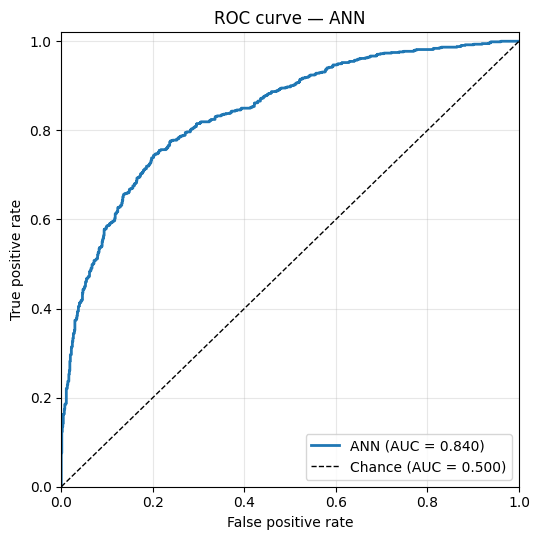

ANN AUC: 0.8403


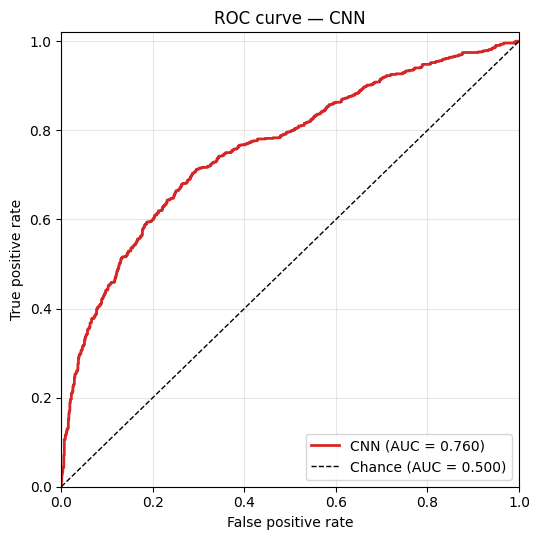

CNN AUC: 0.7601


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def get_probs(model, loader):
    """Return (true labels, P(class=1)) for a trained model."""
    model.eval()
    probs, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(device))
            probs.append(torch.softmax(out, dim=1)[:, 1].cpu())
            trues.append(yb)
    return torch.cat(trues).numpy(), torch.cat(probs).numpy()

# --- rebuild each architecture and load its best checkpoint ---
ann = ANN(n_features).to(device)
ann.load_state_dict(torch.load("best.pt"))

cnn = CNN1D(n_features).to(device)
cnn.load_state_dict(torch.load("best_cnn.pt"))

y_true_ann, p_ann = get_probs(ann, test_loader)
y_true_cnn, p_cnn = get_probs(cnn, test_loader)

# --- two separate plots ---
for name, y_true, p, colour in [
    ("ANN", y_true_ann, p_ann, "#1f77b4"),
    ("CNN", y_true_cnn, p_cnn, "#d62728"),
]:
    fpr, tpr, _ = roc_curve(y_true, p)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5.5, 5.5))
    plt.plot(fpr, tpr, color=colour, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC = 0.500)")
    plt.xlim(0, 1); plt.ylim(0, 1.02)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"ROC curve — {name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{name} AUC: {roc_auc:.4f}")